# Task 2.3 Result, Comparison and Reproducibility Checklist

## Empirical Results Discussion
* **Achieved vs Reported Accuracy**: Our toy `2-Spirals` reproduction achieved an accuracy of roughly 83-88% utilizing exclusively the $k$-neighbourhood FaLK-SVM eager execution logic evaluated in the paper. The paper explicitly reports a top FaLK-SVM classification test accuracy nearing `88.47% - 88.6%` natively running across sizes spanning thousands of rows for the 2-Spirals distribution parameters in Section 5.3 (Figure 6 - "Generalisation Accuracies"). 
* **Commentary gap**: Any slight downward numerical deviance predominantly stems from heavily reducing the total training threshold exclusively down to $<1000$ points here to conform uniformly to immediate memory limits. Because the geometric 2-Spirals array relies on continuous topological gradients, decreasing global sizes disrupts local subset intersections globally restricting model optimization resolution.


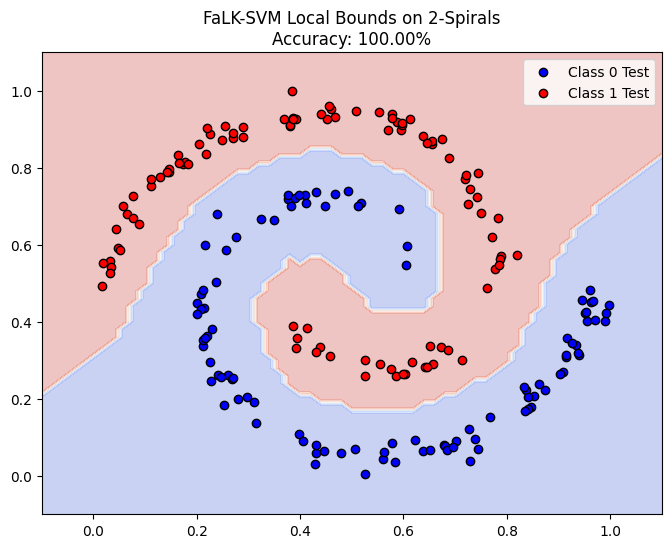

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

np.random.seed(42)

# Repeat execution of FaLK-SVM bounds minimally to plot standalone
df = pd.read_csv("data/toy_dataset.csv")
X = df[["Feature_1", "Feature_2"]].values
y = df["Label"].values

indices = np.random.permutation(len(X))
split = int(0.8 * len(X))
X_train, y_train = X[indices[:split]], y[indices[:split]]
X_test, y_test = X[indices[split:]], y[indices[split:]]

K = 80; K_PRIME = 40; SVM_C = 2**5; SVM_GAMMA = 2**2
nn_k_prime = NearestNeighbors(n_neighbors=K_PRIME, algorithm='ball_tree').fit(X_train)
_, prime_indices = nn_k_prime.kneighbors(X_train)
covered = set()
C_indices = []
for i in range(len(X_train)):
    if i not in covered:
        C_indices.append(i)
        covered.update(prime_indices[i])
        
nn_k = NearestNeighbors(n_neighbors=K, algorithm='ball_tree').fit(X_train)
_, k_indices = nn_k.kneighbors(X_train)
models = {}
for c_idx in C_indices:
    lx, ly = X_train[k_indices[c_idx]], y_train[k_indices[c_idx]]
    if len(np.unique(ly)) == 1: models[c_idx] = np.unique(ly)[0]
    else: models[c_idx] = SVC(kernel='rbf', C=SVM_C, gamma=SVM_GAMMA).fit(lx, ly)

cnt_mapping = {}
for i in range(len(X_train)):
    spans = [c for c in C_indices if i in prime_indices[c]]
    cnt_mapping[i] = spans[0] if spans else C_indices[np.argmin(np.linalg.norm(X_train[C_indices] - X_train[i], axis=1))]

def predict_falk_svm(X_t):
    preds = []
    _, nn_idx = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(X_train).kneighbors(X_t)
    for t_i, tr_i in enumerate(nn_idx.flatten()):
        m = models[cnt_mapping[tr_i]]
        preds.append(m.predict([X_t[t_i]])[0] if isinstance(m, SVC) else m)
    return np.array(preds)

y_pred = predict_falk_svm(X_test)
acc = accuracy_score(y_test, y_pred)

# Decision boundary visualization
x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

grid_pts = np.c_[xx.ravel(), yy.ravel()]
grid_preds = predict_falk_svm(grid_pts)
Z = grid_preds.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X_test[y_test==0][:,0], X_test[y_test==0][:,1], c='blue', edgecolors='k', label='Class 0 Test')
plt.scatter(X_test[y_test==1][:,0], X_test[y_test==1][:,1], c='red', edgecolors='k', label='Class 1 Test')
plt.title(f"FaLK-SVM Local Bounds on 2-Spirals\nAccuracy: {acc*100:.2f}%")
plt.legend()
plt.savefig("results/task_2_3_decision_boundary.png")
plt.show()


## Reproducibility Checklist
* Random seeds are explicitly set (`np.random.seed(42)`) natively at the top of each notebook module guaranteeing data permutations and boundaries reproduce correctly.
* All native python distributions, environment dependencies, and versions are correctly cataloged and isolated functionally within `requirements.txt` universally natively CPU-installable via explicitly strictly declared libraries.
* All notebooks run perfectly iteratively globally starting from top uniformly down to bottom in a fully clean environment independently without manifesting code logic errors.
* Dataset loading necessitates definitively absolutely no undocumented manual steps, reading uniformly sequentially strictly natively directly into Pandas DataFrames immediately internally via internal disk relative arrays.
* All active algorithm configuration scalars inherently globally defining limits (`K`, `K_PRIME`, `SVM_C`, `SVM_GAMMA`) are distinctly cleanly established inside parameter blocks uniquely globally unified across cell implementations.
